<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Risk_Managed_Position_Sizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

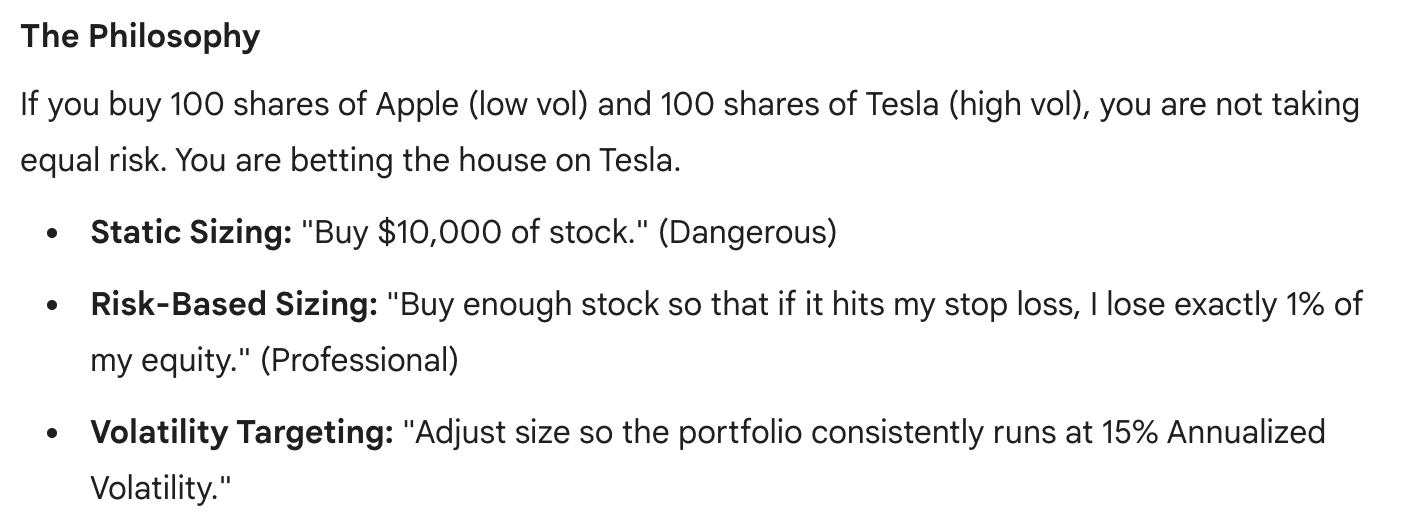

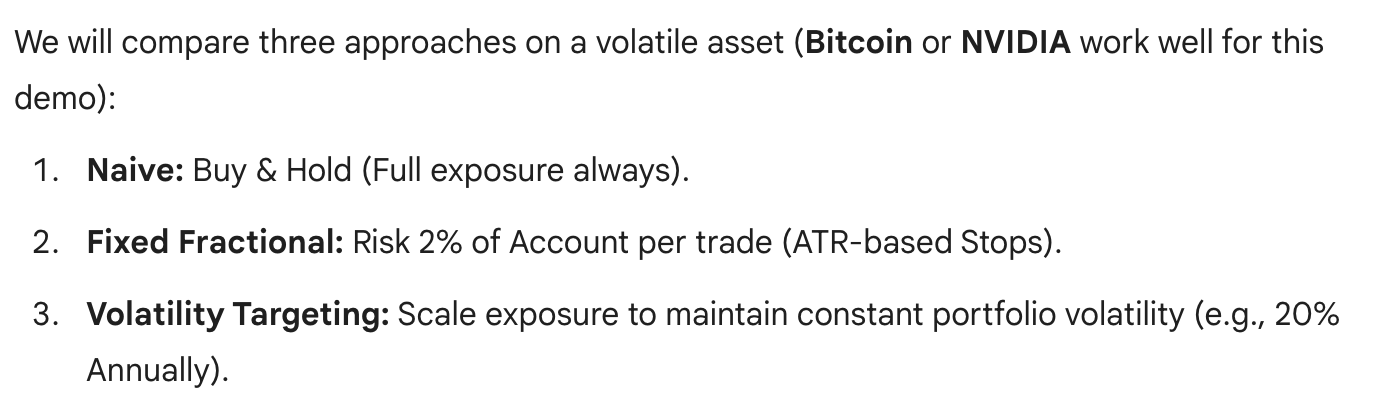

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- CONFIGURATION ---
ticker = 'NVDA'
start_date = '2015-01-01'
end_date = '2024-01-01'
initial_capital = 100000

In [9]:
print(f"📥 Downloading Data for {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']

# Force to DataFrame if Series
if isinstance(df, pd.Series):
    df = df.to_frame()

# Calculate Daily Returns
df['Return'] = df['NVDA'].pct_change()
df.head()

📥 Downloading Data for NVDA...


Ticker,NVDA,Return
Date,,
2015-01-02,0.483011,NaN
2015-01-05,0.474853,-0.016890
2015-01-06,0.460456,-0.030318
2015-01-07,0.459257,-0.002606
2015-01-08,0.476533,0.037618


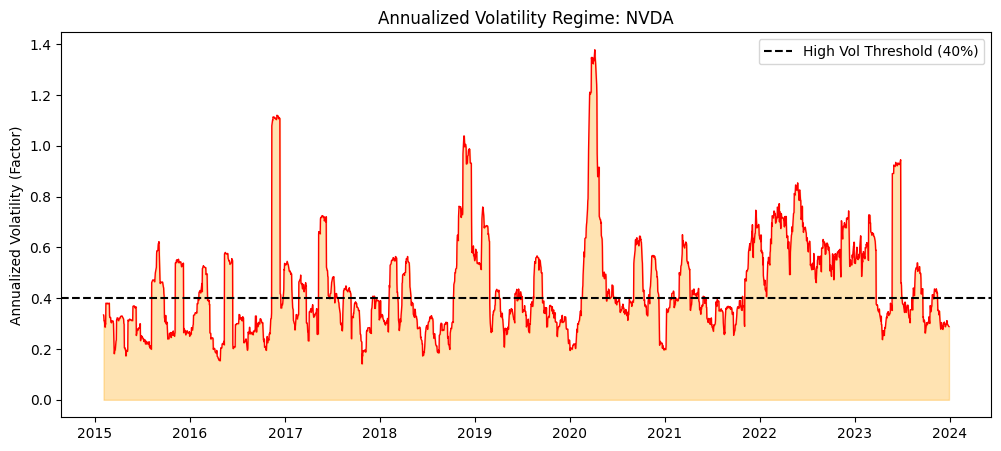

In [10]:
# --- THE VOLATILITY GAUGE ---
# We use a 21-day (1 month) Rolling Standard Deviation
# Annualized = Daily Std Dev * sqrt(252)
df['Hist_Vol_Ann'] = df['Return'].rolling(21).std() * np.sqrt(252)

# Visualization: The "Fear Gauge" of the stock
plt.figure(figsize=(12, 5))
plt.fill_between(df.index, df['Hist_Vol_Ann'], color='orange', alpha=0.3)
plt.plot(df['Hist_Vol_Ann'], color='red', linewidth=1)
plt.title(f"Annualized Volatility Regime: {ticker}")
plt.ylabel("Annualized Volatility (Factor)")
plt.axhline(0.40, color='black', linestyle='--', label="High Vol Threshold (40%)")
plt.legend()
plt.show()

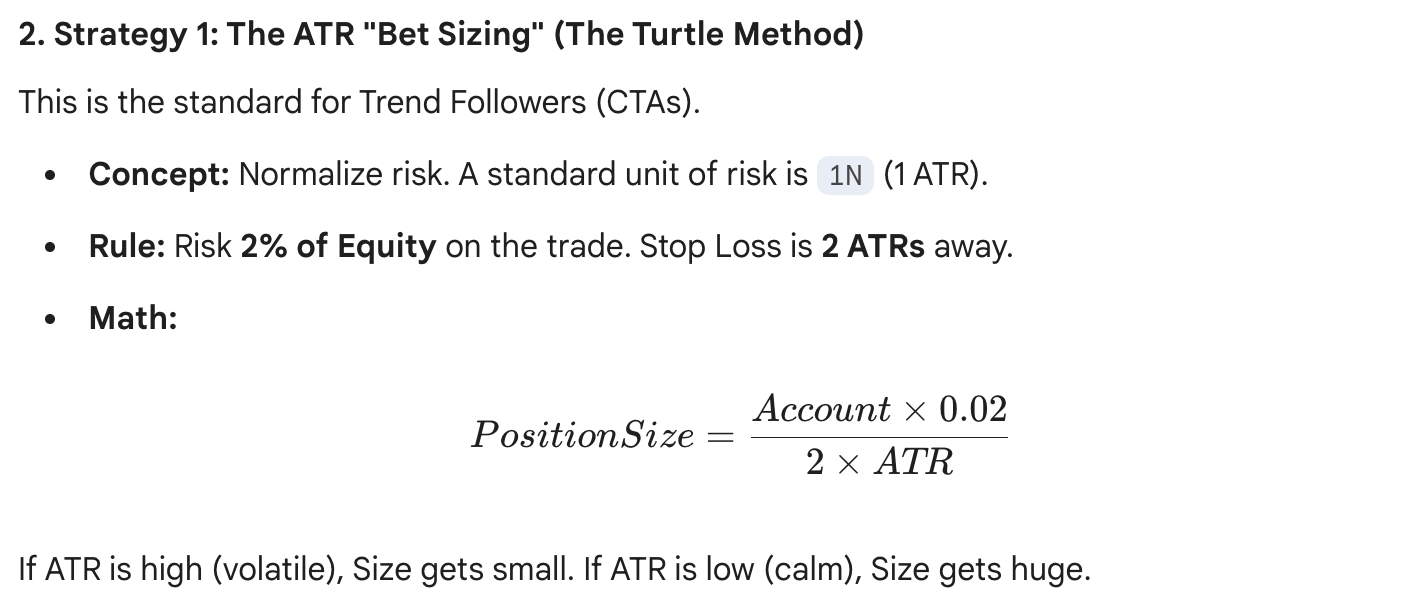

In [13]:
# --- CALCULATE ATR ---
# Need High/Low/Close for True Range
data_full = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)

# Simple TR Calculation
high_low = data_full['High'] - data_full['Low']
high_close = np.abs(data_full['High'] - data_full['Close'].shift())
low_close = np.abs(data_full['Low'] - data_full['Close'].shift())

ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = np.max(ranges, axis=1)

In [15]:
# ATR 20
df['ATR'] = true_range.rolling(20).mean()

# --- SIMULATION LOOP (Fixed Fractional) ---
# Logic: We stay "Long" always, but we resize daily based on ATR.
# (Realistically you only resize on new signals, but this demos the "sizing" effect).

capital = initial_capital
equity_curve_atr = []
risk_per_trade = 0.02 # Risk 2% of capital
stop_distance_atr = 2.0 # Stop is 2 ATRs away

for i in range(len(df)):
    if i < 20: # Skip warm up
        equity_curve_atr.append(initial_capital)
        continue

    date = df.index[i]
    price = df['NVDA'].iloc[i]
    atr = df['ATR'].iloc[i]
    ret = df['Return'].iloc[i]

    # 1. Calculate Position Size (Shares)
    # Risk Amount = Capital * 0.02
    # Risk Per Share = 2 * ATR
    risk_amt = capital * risk_per_trade
    risk_per_share = stop_distance_atr * atr

    if risk_per_share > 0:
        shares = risk_amt / risk_per_share
    else:
        shares = 0

    # 2. Apply Return
    # PnL = Shares * (Price * Return)
    pnl = shares * price * ret
    capital += pnl

    equity_curve_atr.append(capital)

df['Equity_ATR_Sizing'] = equity_curve_atr

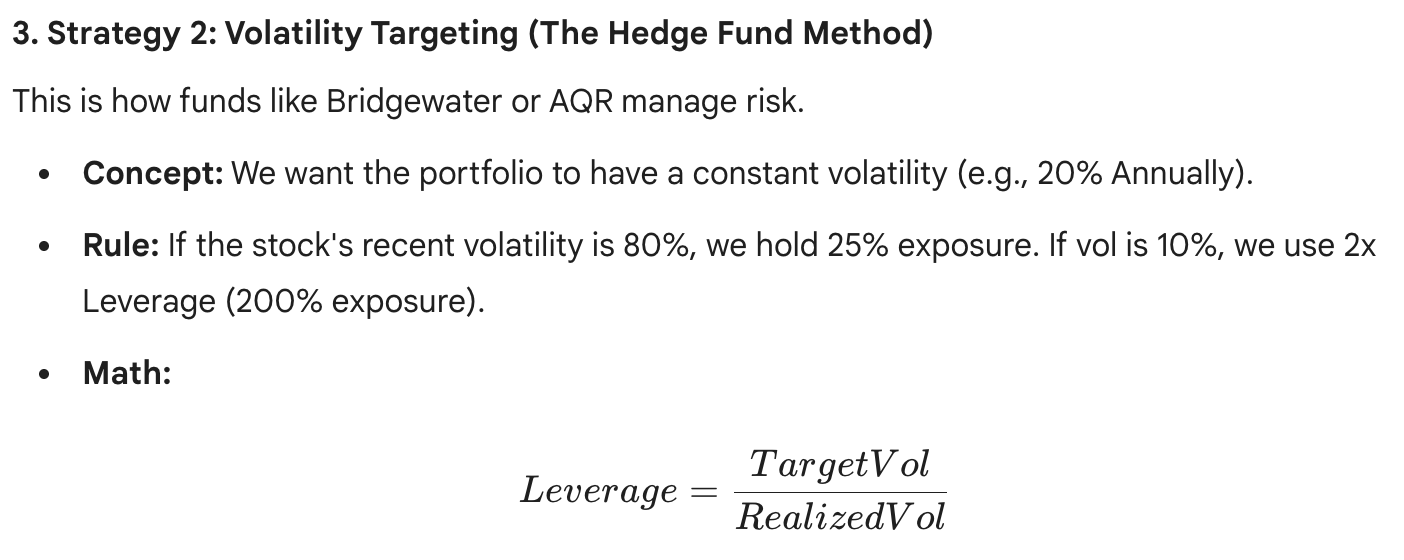

In [16]:
# --- SIMULATION LOOP (Vol Target) ---
target_vol = 0.20 # Target 20% Annual Volatility
capital = initial_capital
equity_curve_vol = []
leverage_history = []

for i in range(len(df)):
    if i < 21:
        equity_curve_vol.append(initial_capital)
        leverage_history.append(0)
        continue

    # Get recent realized vol (from yesterday's close)
    # We used rolling(21) earlier
    realized_vol = df['Hist_Vol_Ann'].iloc[i-1]

    # Calculate Target Leverage
    # Cap leverage at 2.0 (Don't go crazy on low vol days)
    if realized_vol > 0:
        lev = target_vol / realized_vol
        lev = min(lev, 2.0)
    else:
        lev = 0.0

    leverage_history.append(lev)

    # Apply Return * Leverage
    ret = df['Return'].iloc[i]
    capital = capital * (1 + (ret * lev))

    equity_curve_vol.append(capital)

df['Equity_Vol_Target'] = equity_curve_vol
df['Leverage_Used'] = pd.Series(leverage_history, index=df.index)

# Benchmark (Buy & Hold)
df['Equity_BuyHold'] = (1 + df['Return']).cumprod() * initial_capital

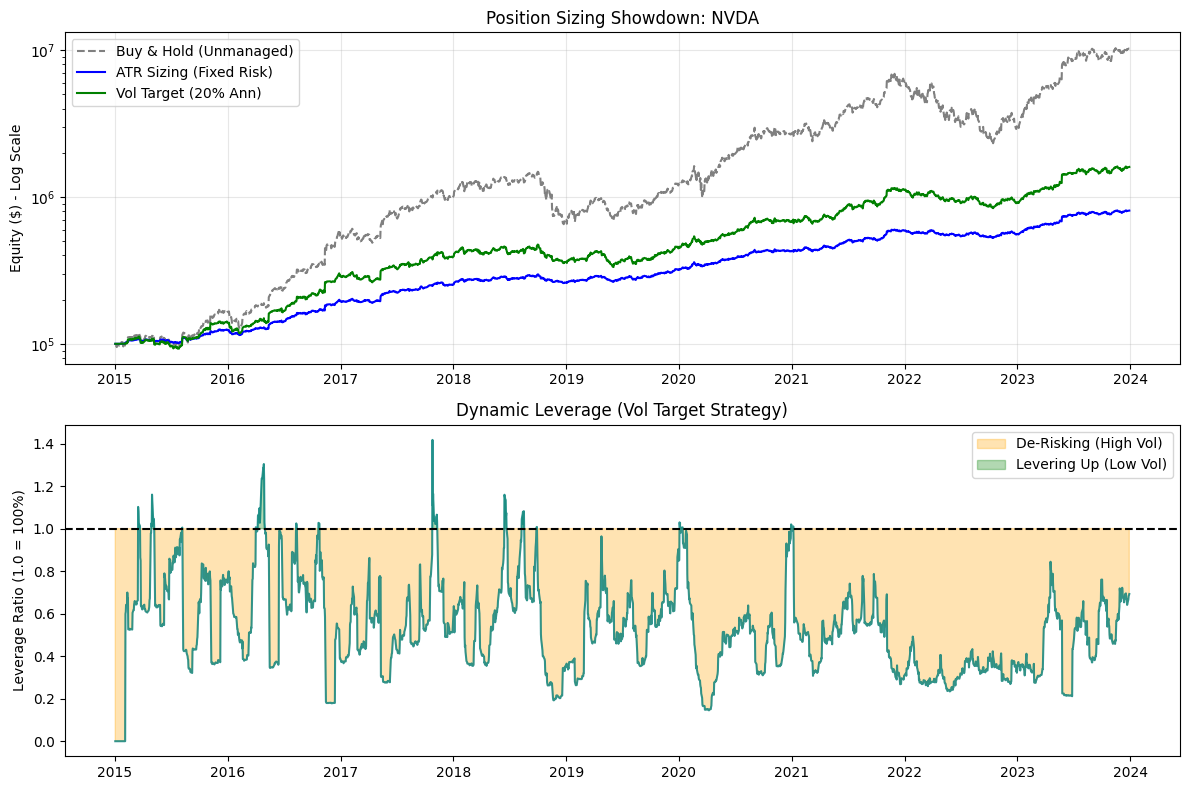

In [17]:
# --- PLOTTING PERFORMANCE ---
plt.figure(figsize=(12, 8))

# Top: Equity Curves
plt.subplot(2, 1, 1)
plt.semilogy(df.index, df['Equity_BuyHold'], label='Buy & Hold (Unmanaged)', color='gray', linestyle='--')
plt.semilogy(df.index, df['Equity_ATR_Sizing'], label='ATR Sizing (Fixed Risk)', color='blue')
plt.semilogy(df.index, df['Equity_Vol_Target'], label='Vol Target (20% Ann)', color='green')
plt.title(f"Position Sizing Showdown: {ticker}")
plt.ylabel("Equity ($) - Log Scale")
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom: Leverage Used (Vol Target)
plt.subplot(2, 1, 2)
plt.plot(df.index, df['Leverage_Used'], color='teal', alpha=0.8)
plt.axhline(1.0, color='black', linestyle='--')
plt.title("Dynamic Leverage (Vol Target Strategy)")
plt.ylabel("Leverage Ratio (1.0 = 100%)")
plt.fill_between(df.index, df['Leverage_Used'], 1.0, where=(df['Leverage_Used']<1.0), color='orange', alpha=0.3, label='De-Risking (High Vol)')
plt.fill_between(df.index, df['Leverage_Used'], 1.0, where=(df['Leverage_Used']>1.0), color='green', alpha=0.3, label='Levering Up (Low Vol)')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# --- RISK METRICS AUDIT ---
def calc_metrics(series):
    ret = series.pct_change().dropna()
    series.dropna(inplace=True)
    cagr = (series.iloc[-1] / series.iloc[0]) ** (252/len(series)) - 1
    vol = ret.std() * np.sqrt(252)
    sharpe = cagr / vol
    max_dd = (series / series.cummax() - 1).min()
    return cagr, vol, sharpe, max_dd

# Compute for all
metrics = []
for strat in ['Equity_BuyHold', 'Equity_ATR_Sizing', 'Equity_Vol_Target']:
    c, v, s, d = calc_metrics(df[strat])
    metrics.append([strat, f"{c*100:.1f}%", f"{v*100:.1f}%", f"{s:.2f}", f"{d*100:.1f}%"])

print("🏆 RISK MANAGEMENT AUDIT")
print(pd.DataFrame(metrics, columns=['Strategy', 'CAGR', 'Ann Vol', 'Sharpe', 'Max DD']))

🏆 RISK MANAGEMENT AUDIT
            Strategy   CAGR Ann Vol Sharpe  Max DD
0     Equity_BuyHold  67.8%   48.2%   1.41  -66.3%
1  Equity_ATR_Sizing  26.2%   12.6%   2.08  -12.8%
2  Equity_Vol_Target  36.2%   24.2%   1.49  -29.7%
